EXPERIMENT 3
Policy and Value Function Representation using Bellman Equations


FINAL RESULTS
A       --->  49.05
B       --->  54.50
C       --->  55.00
Goal    --->  50.00


OPTIMAL POLICY
A       --->  Move to B
B       --->  Move to C
C       --->  Move to Goal
Goal    --->  Terminal


SUMMARY TABLE
  State  Reward  Final_Value Optimal_Policy
0     A       0        49.05      Move to B
1     B       5        54.50      Move to C
2     C      10        55.00   Move to Goal
3  Goal      50        50.00       Terminal


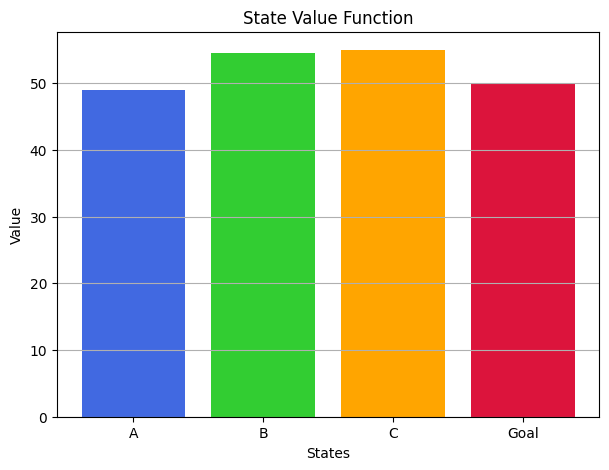

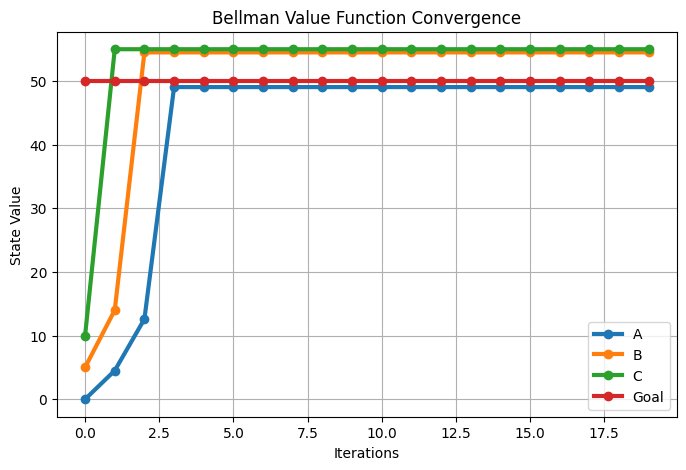

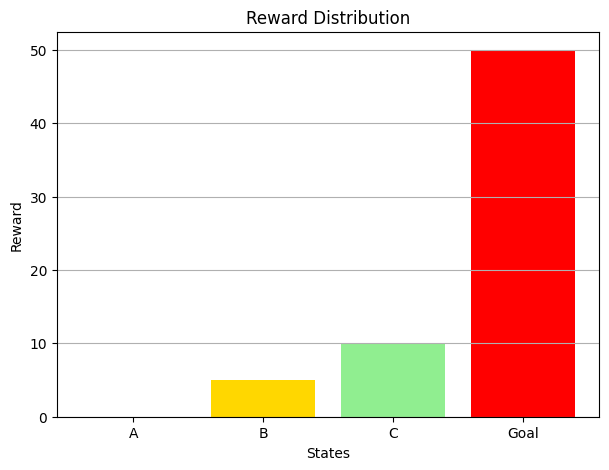

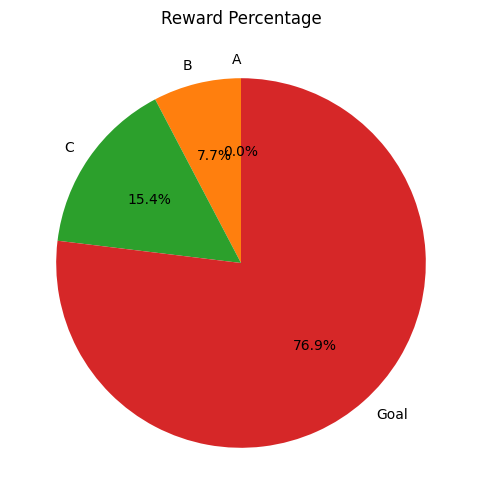

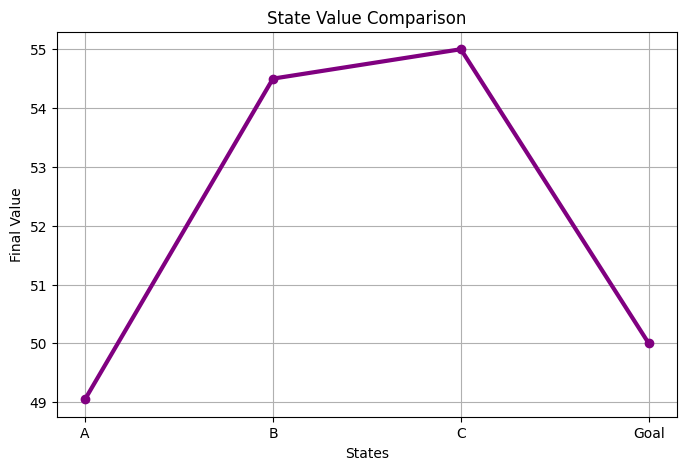



PERFORMANCE METRICS
Maximum State Value : 55.0
Minimum State Value : 49.05
Average State Value : 52.14
Total Reward : 65
Discount Factor : 0.9
Iterations : 20


CONCLUSION
The Bellman Equation successfully computed the
optimal value function for every state.
The state values converged after repeated
iterations, and the optimal policy directs
the agent toward the Goal state.

Bellman_Summary.csv has been saved successfully.


In [ ]:
# ===============================================================
# EXPERIMENT 3
# Policy and Value Function Representation using Bellman Equations
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# AIM
# -------------------------------
print("="*70)
print("EXPERIMENT 3")
print("Policy and Value Function Representation using Bellman Equations")
print("="*70)

# -------------------------------
# Define States
# -------------------------------

states = ["A","B","C","Goal"]

# -------------------------------
# Rewards
# -------------------------------

rewards = np.array([0,5,10,50])

# -------------------------------
# Discount Factor
# -------------------------------

gamma = 0.90

# -------------------------------
# Initialize Values
# -------------------------------

values = np.zeros(len(states))

iterations = 20

history = []

# -------------------------------
# Bellman Value Iteration
# -------------------------------

for itr in range(iterations):

    new_values = values.copy()

    for s in range(len(states)-1):

        new_values[s] = rewards[s] + gamma*values[s+1]

    new_values[-1] = rewards[-1]

    values = new_values

    history.append(values.copy())

history = np.array(history)

# -------------------------------
# Optimal Policy
# -------------------------------

policy=[]

for i in range(len(states)):

    if i==len(states)-1:

        policy.append("Terminal")

    else:

        policy.append("Move to "+states[i+1])

# -------------------------------
# RESULTS
# -------------------------------

print("\n")
print("="*70)
print("FINAL RESULTS")
print("="*70)

for s,v in zip(states,values):

    print(f"{s:6s}  --->  {v:.2f}")

print("\n")

print("="*70)
print("OPTIMAL POLICY")
print("="*70)

for s,p in zip(states,policy):

    print(f"{s:6s}  --->  {p}")

# -------------------------------
# SUMMARY TABLE
# -------------------------------

summary = pd.DataFrame({

"State":states,

"Reward":rewards,

"Final_Value":np.round(values,2),

"Optimal_Policy":policy

})

print("\n")
print("="*70)
print("SUMMARY TABLE")
print("="*70)
print(summary)

summary.to_csv("Bellman_Summary.csv",index=False)

# -------------------------------
# VISUALIZATION 1
# State Values
# -------------------------------

plt.figure(figsize=(7,5))

colors=["royalblue","limegreen","orange","crimson"]

plt.bar(states,values,color=colors)

plt.title("State Value Function")

plt.xlabel("States")

plt.ylabel("Value")

plt.grid(axis='y')

plt.show()

# -------------------------------
# VISUALIZATION 2
# Bellman Convergence
# -------------------------------

plt.figure(figsize=(8,5))

for i in range(len(states)):

    plt.plot(history[:,i],
             linewidth=3,
             marker='o',
             label=states[i])

plt.title("Bellman Value Function Convergence")

plt.xlabel("Iterations")

plt.ylabel("State Value")

plt.legend()

plt.grid()

plt.show()

# -------------------------------
# VISUALIZATION 3
# Reward Distribution
# -------------------------------

plt.figure(figsize=(7,5))

plt.bar(states,
        rewards,
        color=["skyblue","gold","lightgreen","red"])

plt.title("Reward Distribution")

plt.xlabel("States")

plt.ylabel("Reward")

plt.grid(axis='y')

plt.show()

# -------------------------------
# VISUALIZATION 4
# Pie Chart
# -------------------------------

plt.figure(figsize=(6,6))

plt.pie(rewards,
        labels=states,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Reward Percentage")

plt.show()

# -------------------------------
# VISUALIZATION 5
# State Value Comparison
# -------------------------------

plt.figure(figsize=(8,5))

plt.plot(states,
         values,
         color="purple",
         marker="o",
         linewidth=3)

plt.title("State Value Comparison")

plt.xlabel("States")

plt.ylabel("Final Value")

plt.grid()

plt.show()

# -------------------------------
# PERFORMANCE METRICS
# -------------------------------

print("\n")
print("="*70)
print("PERFORMANCE METRICS")
print("="*70)

print("Maximum State Value :",round(np.max(values),2))

print("Minimum State Value :",round(np.min(values),2))

print("Average State Value :",round(np.mean(values),2))

print("Total Reward :",np.sum(rewards))

print("Discount Factor :",gamma)

print("Iterations :",iterations)

# -------------------------------
# CONCLUSION
# -------------------------------

print("\n")
print("="*70)
print("CONCLUSION")
print("="*70)

print("The Bellman Equation successfully computed the")
print("optimal value function for every state.")
print("The state values converged after repeated")
print("iterations, and the optimal policy directs")
print("the agent toward the Goal state.")

print("\nBellman_Summary.csv has been saved successfully.")